In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
# Model saving
import pickle
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

print('All libraries imported successfully!')

All libraries imported successfully!


In [2]:
# Load data
df = pd.read_csv('customer_data.csv')

# Handle missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode categorical variables
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
                    'MultipleLines', 'InternetService', 'OnlineSecurity',
                    'OnlineBackup', 'DeviceProtection', 'TechSupport',
                    'StreamingTV', 'StreamingMovies', 'Contract',
                    'PaperlessBilling', 'PaymentMethod']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})

# Separate features and target
X = df_encoded.drop(['customerID', 'Churn'], axis=1)
y = df_encoded['Churn']

# Fix NaN and convert
X = X.fillna(0).astype(float)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples: {X_test.shape[0]}')
print('Data ready! ✅')

Training samples: 5634
Test samples: 1409
Data ready! ✅


In [3]:
# Baseline Random Forest (from Week 2)
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train, y_train)

# Evaluate
y_pred_baseline = rf_baseline.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f'Baseline Random Forest Accuracy: {baseline_accuracy:.4f}')
print('\nBaseline Classification Report:')
print(classification_report(y_test, y_pred_baseline))

Baseline Random Forest Accuracy: 0.7850

Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.50      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



Cross-Validation Results:
Scores for each fold: [0.80390417 0.79769299 0.78881988 0.77196096 0.77975133]
Mean CV Score: 0.7884
Standard Deviation: 0.0116


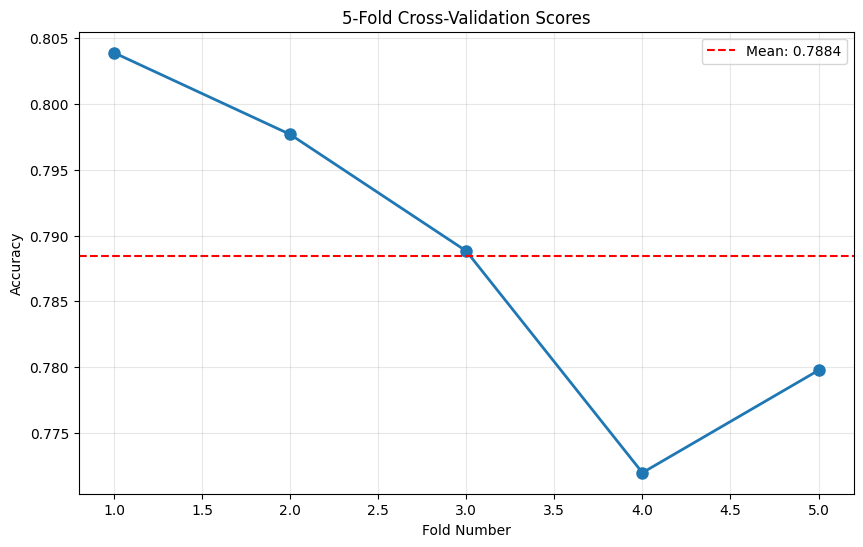

In [4]:
# 5-fold cross-validation
rf_cv = RandomForestClassifier(n_estimators=100, random_state=42)

cv_scores = cross_val_score(rf_cv, X_train, y_train, cv=5, scoring='accuracy')

print('Cross-Validation Results:')
print(f'Scores for each fold: {cv_scores}')
print(f'Mean CV Score: {cv_scores.mean():.4f}')
print(f'Standard Deviation: {cv_scores.std():.4f}')

# Visualize
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), cv_scores, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.title('5-Fold Cross-Validation Scores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

print(f'Total combinations: {3*4*3*3*2} × 5 folds = {3*4*3*3*2*5} trainings!')
print('Starting Grid Search... please wait ⏳')

import time
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_search.fit(X_train, y_train)
end = time.time()

print(f'\nCompleted in {(end-start)/60:.2f} minutes!')
print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best CV Score: {grid_search.best_score_:.4f}')

# Evaluate on test set
best_rf = grid_search.best_estimator_
y_pred_optimized = best_rf.predict(X_test)
optimized_accuracy = accuracy_score(y_test, y_pred_optimized)
print(f'\nBaseline Accuracy: {baseline_accuracy:.4f}')
print(f'Optimized Accuracy: {optimized_accuracy:.4f}')
print(f'Improvement: +{(optimized_accuracy - baseline_accuracy):.4f}')

Total combinations: 216 × 5 folds = 1080 trainings!
Starting Grid Search... please wait ⏳
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Completed in 6.04 minutes!
Best Parameters: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Score: 0.8017

Baseline Accuracy: 0.7850
Optimized Accuracy: 0.8041
Improvement: +0.0192


In [6]:
# Basic XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print(f'XGBoost Accuracy: {xgb_accuracy:.4f}')
print('\nXGBoost Classification Report:')
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7928

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [7]:
# XGBoost parameter grid
xgb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=xgb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print('Tuning XGBoost... please wait ⏳')
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
print(f'\nBest XGBoost Parameters:')
print(xgb_grid.best_params_)

y_pred_xgb_opt = best_xgb.predict(X_test)
xgb_opt_accuracy = accuracy_score(y_test, y_pred_xgb_opt)
print(f'\nBasic XGBoost:     {xgb_accuracy:.4f}')
print(f'Optimized XGBoost: {xgb_opt_accuracy:.4f}')
print(f'Improvement: +{(xgb_opt_accuracy - xgb_accuracy):.4f}')

Tuning XGBoost... please wait ⏳
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best XGBoost Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}

Basic XGBoost:     0.7928
Optimized XGBoost: 0.8027
Improvement: +0.0099


Model Comparison:
                  Model  Accuracy  Precision   Recall  F1-Score
Optimized Random Forest  0.804116   0.678832 0.497326  0.574074
      Optimized XGBoost  0.802697   0.661074 0.526738  0.586310
          Basic XGBoost  0.792761   0.628931 0.534759  0.578035
 Baseline Random Forest  0.784954   0.617940 0.497326  0.551111

🏆 Best Model: Optimized Random Forest with 0.8041 accuracy


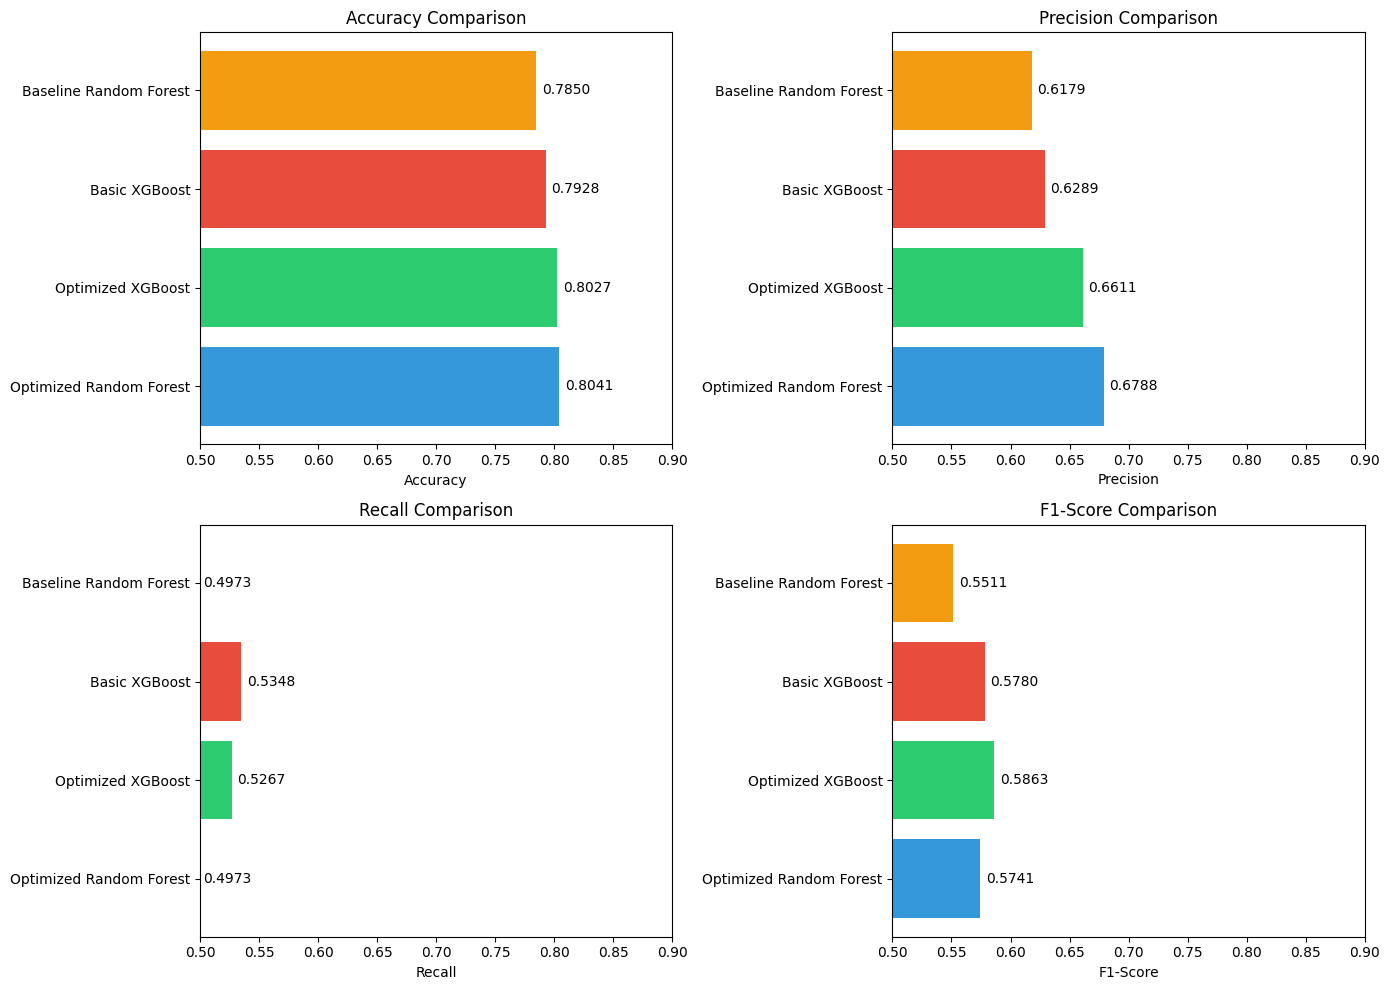

In [8]:
# Create comparison table
models = {
    'Baseline Random Forest': y_pred_baseline,
    'Optimized Random Forest': y_pred_optimized,
    'Basic XGBoost': y_pred_xgb,
    'Optimized XGBoost': y_pred_xgb_opt
}

comparison_data = []
for name, predictions in models.items():
    comparison_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions),
        'Recall': recall_score(y_test, predictions),
        'F1-Score': f1_score(y_test, predictions)
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)
print('Model Comparison:')
print(comparison_df.to_string(index=False))

best_model_name = comparison_df.iloc[0]['Model']
best_accuracy = comparison_df.iloc[0]['Accuracy']
print(f'\n🏆 Best Model: {best_model_name} with {best_accuracy:.4f} accuracy')

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_list = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    ax.barh(comparison_df['Model'], comparison_df[metric], color=colors_list)
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} Comparison')
    ax.set_xlim(0.5, 0.9)
    for i, v in enumerate(comparison_df[metric]):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

In [9]:
# Save the best model (Optimized Random Forest)
model_filename = 'best_churn_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_rf, file)
print(f'✅ Model saved as {model_filename}')

# Verify by loading it back
with open(model_filename, 'rb') as file:
    loaded_model = pickle.load(file)

test_predictions = loaded_model.predict(X_test[:5])
print(f'Test predictions from loaded model: {test_predictions}')
print('Model loading verified! ✅')

# Save metadata
import json
metadata = {
    'model_type': 'Optimized Random Forest',
    'accuracy': optimized_accuracy,
    'precision': float(precision_score(y_test, y_pred_optimized)),
    'recall': float(recall_score(y_test, y_pred_optimized)),
    'f1_score': float(f1_score(y_test, y_pred_optimized)),
    'best_params': grid_search.best_params_,
    'features': list(X.columns)
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)
print('✅ Metadata saved as model_metadata.json')

✅ Model saved as best_churn_model.pkl
Test predictions from loaded model: [0 1 0 0 0]
Model loading verified! ✅
✅ Metadata saved as model_metadata.json


In [10]:
print("=" * 55)
print("LAB 3 SUMMARY - MODEL OPTIMIZATION")
print("=" * 55)
print(f"\n📊 Cross-Validation (5-Fold):")
print(f"   Mean Accuracy: {cv_scores.mean():.4f}")
print(f"   Std Deviation: {cv_scores.std():.4f}")
print(f"\n🔧 Hyperparameter Tuning Results:")
print(f"   Baseline RF:       {baseline_accuracy:.4f}")
print(f"   Optimized RF:      {optimized_accuracy:.4f} (+{optimized_accuracy-baseline_accuracy:.4f})")
print(f"   Basic XGBoost:     {xgb_accuracy:.4f}")
print(f"   Optimized XGBoost: {xgb_opt_accuracy:.4f} (+{xgb_opt_accuracy-xgb_accuracy:.4f})")
print(f"\n🏆 Best Model: Optimized Random Forest")
print(f"   Accuracy: {optimized_accuracy:.4f}")
print(f"   Saved as: best_churn_model.pkl")
print(f"\n✅ Next: Week 4 - Deploy as web app!")

LAB 3 SUMMARY - MODEL OPTIMIZATION

📊 Cross-Validation (5-Fold):
   Mean Accuracy: 0.7884
   Std Deviation: 0.0116

🔧 Hyperparameter Tuning Results:
   Baseline RF:       0.7850
   Optimized RF:      0.8041 (+0.0192)
   Basic XGBoost:     0.7928
   Optimized XGBoost: 0.8027 (+0.0099)

🏆 Best Model: Optimized Random Forest
   Accuracy: 0.8041
   Saved as: best_churn_model.pkl

✅ Next: Week 4 - Deploy as web app!
